# Classificazione delle risposte fornite dagli psicologi
- Prendiamo le risposte degli psicologi e classifichiamo il disturbo del paziente tramite un modello generativo.
- Si aggiunge la classificazione fatta in una nuova colonna del dataset.

In [ ]:
!pip install huggingface_hub
!pip install transformers -U bitsandbytes

In [2]:
# Librerie
import numpy as np
import pandas as pd
import torch
import json
import nltk
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from tqdm.notebook import tqdm
from datasets import Dataset
from peft import LoraConfig, get_peft_model, TaskType

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    AutoModel,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    pipeline
)

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split


from sentence_transformers import SentenceTransformer

from huggingface_hub import notebook_login
from huggingface_hub.hf_api import HfFolder
HfFolder.save_token("TOKEN")

In [10]:
 
df_raw = pd.read_csv('/kaggle/input/nlp-mental-health-conversations/train.csv')

 
df_clean = df_raw.dropna(subset=['Response', 'Context'], how='any')
df = df_clean.copy()

 
df['Response'] = df['Response'].str.replace('\n', ' ', regex=True)
df['Context'] = df['Context'].str.replace('\n', ' ', regex=True)

In [17]:
mental_disorders_df = pd.read_csv('/kaggle/input/mental-disorders/mental_disorders.csv')
mental_disorders_list = mental_disorders_df["Mental Disorder"].tolist()
mental_disorders_str = ", ".join(mental_disorders_list)

In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

model_name = "openchat/openchat-3.5-0106"  
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,  
    bnb_4bit_quant_type="nf4"  
)

classification_model = AutoModelForCausalLM.from_pretrained(
                       model_name, 
                       device_map="auto", 
                       quantization_config=quantization_config)
tokenizer = AutoTokenizer.from_pretrained(model_name)

if tokenizer.pad_token is None:
    print("Tokenizer has no pad token.")
    tokenizer.pad_token = tokenizer.eos_token

In [ ]:
tqdm.pandas(desc="⚙️ Classificando risposte")

# Classificazione
def classification(psycologist):
    system = f"""
    You are a strict mental health classifier.

    You will be given a response written by a psychologist to a patient.

    Your ONLY task is to infer exactly THREE possible mental health disorders that the patient might be experiencing, based on that response.

    You must choose the disorders ONLY from the following list:
    {mental_disorders_str}

    Output ONLY the names of the three disorders, separated by commas, on a single line.

    Do NOT add any explanations, warnings, advice, or extra text. Do NOT refer to the psychologist or the user. Just output the disorders.
    """
    
    chat = [{'role':'system','content':f'{system}'},
            {'role':'user','content': f'{psycologist}'}]
    try:
        tokenized_chat = tokenizer.apply_chat_template(chat, 
                                                       tokenize=True, 
                                                       add_generation_prompt=True,
                                                       truncation=True,
                                                       return_tensors="pt")
        outputs = classification_model.generate(tokenized_chat.to(device),temperature=1,max_length=8192)
        output_str = tokenizer.decode(outputs[0],skip_special_tokens=True)
        first_occurrence = output_str.find("GPT4 Correct Assistant:")
        response = output_str[first_occurrence + len("GPT4 Correct Assistant:"):].strip()
        print(response)
        # Rimuovi eventuali ripetizioni di "GPT4 Correct Assistant:" all'inizio della risposta
        if response.startswith("GPT4 Correct Assistant:"):
            response = response[len("GPT4 Correct Assistant:"):].strip()
    except Exception as e:
        response = 'No classification'
        print(e) 
    return response

 
df['Disorders'] = tqdm(df['Response'].progress_apply(classification))

 
df.to_csv('/kaggle/working/output.csv', index=False)
print("File salvato in /kaggle/working/output.csv")

In [12]:
df= pd.read_csv('/kaggle/input/mental-disorders-with-classification/train_with_classification.csv')

In [13]:
df

,Context,Response,Disorders
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb...","Adjustment Disorder with Depressed Mood, Anxie..."
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see...","Acute Stress Disorder, Adjustment Disorder wit..."
2,I'm going through some things with my feelings...,First thing I'd suggest is getting the sleep y...,"Acute Insomnia, Adjustment Disorder with Depre..."
3,I'm going through some things with my feelings...,Therapy is essential for those that are feelin...,"Acute Stress Disorder, Adjustment Disorder wit..."
4,I'm going through some things with my feelings...,I first want to let you know that you are not ...,"Adjustment Disorder, Anxiety Disorder, Depression"
...,...,...,...
3502,My grandson's step-mother sends him to school ...,Absolutely not! It is never in a child's best ...,"Adjustment Disorders, Anxiety Disorder due to ..."
3503,My boyfriend is in recovery from drug addictio...,I'm sorry you have tension between you and you...,"Acute Stress Disorder, Adjustment Disorder wit..."
3504,The birth mother attempted suicide several tim...,"The true answer is, 'no one can really say wit...","Acute Stress Disorder, Adjustment Disorders, P..."
3505,I think adult life is making him depressed and...,How do you help yourself to believe you requir...,"Acute Stress Disorder, Adjustment Disorder wit..."


In [23]:
df['disorders_list'] = df['Disorders'].str.split(',')

 
exploded = df.explode('disorders_list')

 
disturbo_counts = exploded['disorders_list'].value_counts()

 
mental_disorders_df['count'] = mental_disorders_df['Mental Disorder'].map(disturbo_counts).fillna(0).astype(int)

In [25]:
mental_disorders_df

,Mental Disorder,count
0,Acute Insomnia,79
1,Acute Stress Disorder,2741
2,Adjustment Disorder with Depressed Mood,94
3,Adjustment Disorders,160
4,Alcohol Use Disorder,38
...,...,...
114,Suicidal Risk Disorder,0
115,Suicide Attempt,0
116,Toxic Psychosis,0
117,Toxicomania,0


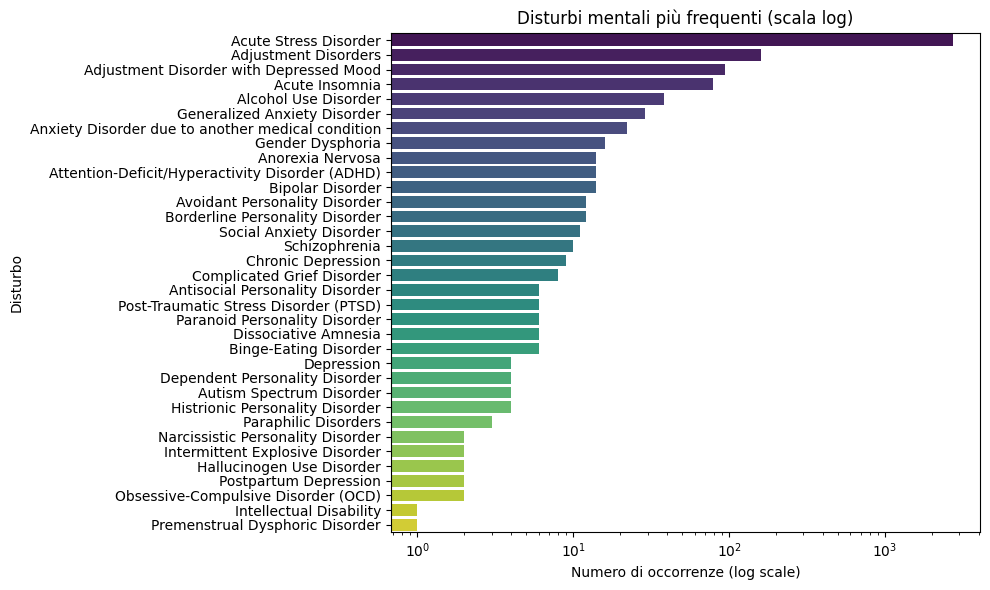

In [32]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

 
filtered_df = mental_disorders_df[mental_disorders_df['count'] > 0].sort_values(by='count', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=filtered_df, x='count', y='Mental Disorder', palette='viridis')

 
ax.set_xscale('log')

 
plt.title('Disturbi mentali più frequenti (scala log)')
plt.xlabel('Numero di occorrenze (log scale)')
plt.ylabel('Disturbo')

plt.tight_layout()
plt.savefig('/kaggle/working/disorders_classification_plot.png', bbox_inches='tight')
plt.show()
